# 06 — Execution-Grounded Training Pairs

Syntax is necessary but not sufficient. This notebook generates pairs where the
generated ARO program must actually *run* — not just parse.

`aro check` catches structural errors. `aro run` catches semantic errors: wrong
prepositions that happen to parse, missing event handlers, broken data flow. A pair
that passes execution is worth far more as training data than one that merely compiles.

**Three generation strategies:**

1. **Mutation** — take a working example from `Examples/`, ask the model to write
   a variation (different domain, added feature, renamed variables). The reference
   expected output validates semantics.
2. **Recombination** — merge two examples into one application. Forces the model
   to reason about how feature sets interact across concerns.
3. **Spec-to-code** — expand a proposal code fragment into a runnable application.
   Grounds abstract spec language in concrete, working programs.
4. **Readme-to-code** — pre-validated pairs from example READMEs: no generation needed,
   just natural-language descriptions paired with the ground-truth code.

A self-repair loop feeds `aro run` errors back to the model (up to 3 attempts).
Successful repairs are saved as bonus debugging pairs.

**Input:**  `../../Examples/` (92 examples with `expected.txt`)
            `../data/02_knowledge/knowledge.json`
**Output:** `../data/05_exec_pairs/exec_pairs.jsonl`
            merged into `../data/02_knowledge/knowledge_pairs.jsonl`

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import json, re, sys, random, subprocess, tempfile, shutil, textwrap
from pathlib import Path
from collections import defaultdict

DATA_OUT    = GLOBAL_OUT_DIR / '../data/05_exec_pairs'
DATA_OUT.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE  = DATA_OUT / 'exec_pairs.jsonl'

# Find aro binary
ARO_BIN = shutil.which('aro') or str(ARO_ROOT / '.build/release/aro')
print(f'ARO binary: {ARO_BIN}')

with open(KB_FILE) as f:
    kb = json.load(f)

print(f'ARO root:   {ARO_ROOT}')
print(f'Examples:   {EXAMPLES_DIR}')
print(f'Knowledge:  {len(kb["actions"])} actions, {len(kb["examples"])} examples')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters
ARO binary: /opt/homebrew/bin/aro
ARO root:   /Users/kris/Projects/ARO-App
Examples:   /Users/kris/Projects/ARO-App/Examples
Knowledge:  60 actions, 110 examples


## Load examples with expected output

In [2]:
def load_example(path):
    p = Path(path)
    aro_files = {}
    for f in sorted(p.rglob('*.aro')):
        aro_files[str(f.relative_to(p))] = f.read_text()
    if not aro_files:
        return None
    return {
        'name':     p.name,
        'dir':      str(p),
        'aro':      aro_files,
        'expected': (p / 'expected.txt').read_text().strip() if (p / 'expected.txt').exists() else None,
        'readme':   (p / 'README.md').read_text()            if (p / 'README.md').exists()   else None,
        'openapi':  (p / 'openapi.yaml').read_text()         if (p / 'openapi.yaml').exists() else None,
    }

examples = []
for d in sorted(EXAMPLES_DIR.iterdir()):
    if not d.is_dir():
        continue
    ex = load_example(d)
    if ex and ex['expected'] is not None:
        examples.append(ex)

def is_deterministic(ex):
    combined = ' '.join(ex['aro'].values()).lower()
    # Skip server/keepalive examples
    if any(kw in combined for kw in ['keepalive', 'start the <http', 'start the <socket']):
        return False
    # Fix 2: skip plugin examples — require compiled external plugins at runtime
    if Path(ex['dir']).joinpath('Plugins').exists():
        return False
    return True

det_examples    = [e for e in examples if is_deterministic(e)]
plugin_examples = [e for e in examples if Path(e['dir']).joinpath('Plugins').exists()]

print(f'Total examples with expected.txt: {len(examples)}')
print(f'Deterministic (runnable):         {len(det_examples)}')
print(f'  Excluded (plugin):              {len(plugin_examples)} — {[e["name"] for e in plugin_examples]}')
print()
for e in det_examples[:5]:
    print(f'  {e["name"]:30s}  {len(e["aro"])} aro file(s)  expected={len(e["expected"].splitlines())} lines')

Total examples with expected.txt: 94
Deterministic (runnable):         59
  Excluded (plugin):              12 — ['AuditLogDemo', 'CSVProcessor', 'CustomPlugin', 'ExternalService', 'GreetingPlugin', 'HashPluginDemo', 'MarkdownRenderer', 'QualifierPlugin', 'QualifierPluginC', 'QualifierPluginPython', 'SQLiteExample', 'ZipService']

  AssertDemo                      1 aro file(s)  expected=14 lines
  AutoPipeline                    1 aro file(s)  expected=25 lines
  Calculator                      2 aro file(s)  expected=22 lines
  CollectionMerge                 1 aro file(s)  expected=41 lines
  Computations                    1 aro file(s)  expected=34 lines


## Build system prompt

In [3]:
# Build a compact action reference for the system prompt
action_lines = []
for a in kb['actions']:
    verbs = ', '.join(a['verbs'][:3])
    preps = ', '.join(a.get('prepositions', [])[:3])
    action_lines.append(f'  {verbs:<28} prepositions: {preps}')
action_ref = '\n'.join(action_lines)

# Pull syntax summary from knowledge base
syntax_summary = kb.get('aro_syntax', '')[:3000]

SYSTEM_PROMPT = f"""You are an expert ARO (Action Result Object) programmer.
ARO is a DSL where every statement is: Verb the <Result> preposition [the] <Object>.

ARO SYNTAX RULES:
{syntax_summary}

AVAILABLE ACTIONS (verb → role):
{action_ref}

RULES:
- Every feature set: (Name: Business Activity) {{ statements }}
- Exactly one Application-Start per application
- Variables are immutable — use a new name for each transformation
- Articles (a/an/the) are optional everywhere
- String concatenation: <a> ++ <b>  (NOT +)
- For-each: For each <item> in <list> {{ ... }}
- Conditions: when <var> = value or when <expr>
- Return an <OK: status> for the <result>.

Output ONLY valid ARO code. No markdown fences unless asked. No explanations unless asked."""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 4008 chars


## Load model

In [4]:
# Auto-load warm-start adapter from notebook 04 if available
model, tokenizer, _, mlx_generate, make_sampler = load_model()

/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit with warm-start adapter...


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 238312.73it/s]

  Adapter: /Volumes/Models/data/../data/adapters/warm_start
Model ready.


## Execution validator

Runs generated ARO code in a temp directory and checks:
1. Exit code 0
2. Output matches `expected` (if provided) — fuzzy match on key lines

In [5]:
RUN_TIMEOUT = 15   # seconds — enough for non-server examples

def write_temp_app(aro_files, extra_files=None):
    """Write aro_files dict to a temp directory, return Path."""
    tmpdir = Path(tempfile.mkdtemp(prefix='aro_exec_'))
    for rel, content in aro_files.items():
        dest = tmpdir / rel
        dest.parent.mkdir(parents=True, exist_ok=True)
        dest.write_text(content)
    if extra_files:
        for rel, content in extra_files.items():
            dest = tmpdir / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_text(content)
    return tmpdir

def run_aro(tmpdir):
    """Run `aro run <tmpdir>`, return (stdout, stderr, returncode)."""
    try:
        result = subprocess.run(
            [ARO_BIN, 'run', str(tmpdir)],
            capture_output=True, text=True,
            timeout=RUN_TIMEOUT,
            cwd=str(tmpdir),
        )
        return result.stdout.strip(), result.stderr.strip(), result.returncode
    except subprocess.TimeoutExpired:
        return '', 'TIMEOUT', -1
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)

def output_matches(actual, expected, threshold=0.6):
    """Fuzzy match: fraction of expected lines present in actual output."""
    if not expected:
        return True
    exp_lines = [l.strip() for l in expected.splitlines() if l.strip()]
    act_lower  = actual.lower()
    hits = sum(1 for l in exp_lines if l.lower() in act_lower)
    return (hits / len(exp_lines)) >= threshold

def validate_aro(aro_files, expected_output=None, extra_files=None):
    """Returns (ok, stdout, stderr)."""
    tmpdir = write_temp_app(aro_files, extra_files)
    stdout, stderr, rc = run_aro(tmpdir)
    if rc != 0:
        return False, stdout, stderr
    if expected_output and not output_matches(stdout, expected_output):
        return False, stdout, f'Output mismatch. Expected:\n{expected_output}\nGot:\n{stdout}'
    return True, stdout, stderr

print('Validator ready.')

Validator ready.


## Generation helpers

In [6]:
MAX_REPAIR_ATTEMPTS = 3
MAX_NEW_TOKENS      = 1200

def generate(prompt, max_tokens=MAX_NEW_TOKENS, temp=0.6):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    tokens = tokenizer.encode(text)
    out = mlx_generate(
        model, tokenizer,
        prompt=tokens,
        max_tokens=max_tokens,
        sampler=make_sampler(temp=temp),
        verbose=False,
    )
    # Strip any accidental markdown fences
    out = re.sub(r'^```[a-z]*\n?', '', out.strip())
    out = re.sub(r'\n?```$', '', out.strip())
    return out.strip()

def format_aro_files(aro_dict):
    """Format a multi-file example for inclusion in a prompt."""
    parts = []
    for fname, content in aro_dict.items():
        parts.append(f'## {fname}\n{content}')
    return '\n\n'.join(parts)

print('Generation helpers ready.')

Generation helpers ready.


## Generation strategies

### Strategy 1 — Mutation
Ask the model to write a variation of an existing example.

In [7]:
from tqdm import tqdm

MAX_REPAIR_ATTEMPTS = 3
MAX_NEW_TOKENS      = 1200

# Fix 4: global accumulator for error→fix repair pairs (reset by main loop cell)
_repair_pairs = []

def generate(prompt, max_tokens=MAX_NEW_TOKENS, temp=0.6):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    tokens = tokenizer.encode(text)
    out = mlx_generate(
        model, tokenizer,
        prompt=tokens,
        max_tokens=max_tokens,
        sampler=make_sampler(temp=temp),
        verbose=False,
    )
    out = re.sub(r'^```[a-z]*\n?', '', out.strip())
    out = re.sub(r'\n?```$', '', out.strip())
    return out.strip()

def format_aro_files(aro_dict):
    parts = []
    for fname, content in aro_dict.items():
        parts.append(f'## {fname}\n{content}')
    return '\n\n'.join(parts)

MUTATION_TYPES = [
    "Change the data values (use different names, numbers, or strings) but keep the same structure.",
    "Add one extra computation or log statement to demonstrate an additional operation.",
    "Simplify the example to its minimal form while keeping it runnable.",
    "Rename the variables to use a different domain (e.g. change 'user' to 'product').",
    "Add a when-guard condition that filters based on one of the computed values.",
    "Extend with a for-each loop that iterates over a small hardcoded list.",
]

# Fix 5: multiple instruction phrasings for diversity
INSTRUCTION_PHRASINGS = [
    lambda name, src, mut: (
        f"Here is an ARO program called '{name}':\n\n{src}\n\n"
        f"Write a variation that: {mut}\n"
        f"Output only the complete ARO source. "
        f"If multiple files are needed, separate them with '## filename.aro' headers."
    ),
    lambda name, src, mut: (
        f"Given this ARO program '{name}':\n\n{src}\n\n"
        f"Rewrite it to: {mut.rstrip('.')}\n"
        f"Output only the complete ARO source. "
        f"Use '## filename.aro' headers for multiple files."
    ),
    lambda name, src, mut: (
        f"I have an ARO application '{name}':\n\n{src}\n\n"
        f"Please modify it to: {mut.rstrip('.')}\n"
        f"Output only the modified ARO source. "
        f"Use '## filename.aro' headers for multiple files."
    ),
]

def mutate_example(ex):
    mutation    = random.choice(MUTATION_TYPES)
    src         = format_aro_files(ex['aro'])
    phrasing    = random.choice(INSTRUCTION_PHRASINGS)
    instruction = phrasing(ex['name'], src, mutation)
    return instruction, mutation

def try_generate_and_validate(instruction, reference_example=None, strategy='mutation', label=''):
    """
    Generates code, validates with aro run, self-repairs on failure.
    Returns (pair_dict, reason) or (None, reason).
    Fix 4: successful error→fix repairs are appended to the global _repair_pairs list.
    """
    global _repair_pairs
    tag = f'[{strategy[:3]}] {label}' if label else f'[{strategy[:3]}]'

    def parse_output(text):
        file_re = re.compile(r'^##\s+(\S+\.aro)', re.MULTILINE)
        parts = file_re.split(text)
        if len(parts) == 1:
            return {'main.aro': text}
        files = {}
        for i in range(1, len(parts), 2):
            fname   = parts[i].strip()
            content = parts[i+1].strip() if i+1 < len(parts) else ''
            files[fname] = content
        return files

    extra = {'openapi.yaml': reference_example['openapi']} if reference_example and reference_example.get('openapi') else None

    generated  = generate(instruction)
    aro_files  = parse_output(generated)
    ok, stdout, stderr = validate_aro(aro_files, extra_files=extra)

    repair_count = 0
    while not ok and repair_count < MAX_REPAIR_ATTEMPTS:
        # Snapshot the broken state before attempting repair
        broken_code  = format_aro_files(aro_files) if len(aro_files) > 1 else list(aro_files.values())[0]
        broken_error = (stderr or stdout).strip()[:400]

        repair_count += 1
        repair_prompt = (
            f"{instruction}\n\n"
            f"Your previous attempt failed with this error:\n{stderr or stdout}\n\n"
            f"Fix the ARO code and output only the corrected source."
        )
        generated  = generate(repair_prompt, temp=0.3)
        aro_files  = parse_output(generated)
        ok, stdout, stderr = validate_aro(aro_files, extra_files=extra)

        if ok:
            # Fix 4: save error→fix as a bonus repair training pair
            fixed_code = format_aro_files(aro_files) if len(aro_files) > 1 else list(aro_files.values())[0]
            _repair_pairs.append({
                'instruction': (
                    f"The following ARO code produces an error:\n\n{broken_code}\n\n"
                    f"Error:\n{broken_error}\n\n"
                    f"Fix the code."
                ),
                'output':  fixed_code,
                'source':  'repair',
                'score':   1.0,
                'repairs': 0,
            })

    if not ok:
        err_hint = (stderr or stdout).strip().splitlines()[-1][:80] if (stderr or stdout) else '?'
        tqdm.write(f'  {tag}  ✗  {err_hint}')
        return None, f'failed after {repair_count} repairs: {(stderr or stdout)[:120]}'

    repairs_str = f' +{repair_count}r' if repair_count else ''
    tqdm.write(f'  {tag}  ✓{repairs_str}')

    code_str = format_aro_files(aro_files) if len(aro_files) > 1 else list(aro_files.values())[0]
    pair = {
        'instruction': instruction,
        'output':      code_str,
        'source':      strategy,
        'score':       1.0,
        'exec_stdout': stdout[:500],
        'repairs':     repair_count,
    }
    return pair, f'ok (repairs={repair_count}, output={len(stdout)} chars)'

print('Generation helpers ready.')

Generation helpers ready.


### Strategy 2 — Recombination
Combine two examples into one application.

In [8]:
def recombine_examples(ex_a, ex_b):
    src_a = format_aro_files(ex_a['aro'])
    src_b = format_aro_files(ex_b['aro'])

    instruction = (
        f"Below are two separate ARO programs.\n\n"
        f"Program A — '{ex_a['name']}':\n{src_a}\n\n"
        f"Program B — '{ex_b['name']}':\n{src_b}\n\n"
        f"Write a single ARO application that combines both programs into one. "
        f"Keep all feature sets from both. Merge them into a coherent Application-Start. "
        f"Output only the complete ARO source. Use '## filename.aro' headers if using multiple files."
    )
    return instruction

print('Recombination strategy ready.')

Recombination strategy ready.


### Strategy 3 — Spec-to-code
Generate ARO from a natural-language description extracted from proposals.

In [9]:
# Fix 3: heading filter + code scaffold for spec-to-code

SKIP_HEADINGS = {
    'problem', 'examples', 'example', 'syntax', 'overview', 'introduction',
    'summary', 'notes', 'note', 'warning', 'security warning', 'rationale',
    'motivation', 'background', 'goals', 'non-goals', 'future work',
    'backward compatibility', 'open questions', 'discussion', 'related work',
}

spec_prompts = []
for prop in kb.get('proposals', []):
    for seed in prop.get('qa_seeds', []):
        if seed.get('code_examples'):
            spec_prompts.append({
                'heading':  seed['heading'],
                'code':     seed['code_examples'][0],
                'proposal': seed['proposal'],
            })

def is_good_spec(spec):
    h = spec['heading'].lower().strip()
    # Skip pure section numbers like "1.", "2.1", "7."
    if re.match(r'^[\d\.\s]+$', h):
        return False
    # Skip known abstract/non-code headings
    if any(bad in h for bad in SKIP_HEADINGS):
        return False
    # Require a meaningful code snippet (>30 chars with at least one ARO construct)
    code = spec.get('code', '').strip()
    if len(code) < 30:
        return False
    return True

good_spec_prompts = [s for s in spec_prompts if is_good_spec(s)]
random.shuffle(good_spec_prompts)
print(f'Spec prompts: {len(spec_prompts)} total → {len(good_spec_prompts)} usable')
if good_spec_prompts:
    print(f'  Example: "{good_spec_prompts[0]["heading"]}"')
    print(f'  Snippet: {good_spec_prompts[0]["code"][:80].strip()}...')

def spec_to_code(spec):
    """Fix 3: include the proposal code snippet as a scaffold in the prompt."""
    heading      = spec['heading']
    code_snippet = spec.get('code', '').strip()

    if len(code_snippet) > 30:
        instruction = (
            f"Expand the following ARO code fragment into a complete, runnable application "
            f"that demonstrates: {heading}.\n\n"
            f"Fragment to build upon:\n{code_snippet}\n\n"
            f"Requirements: exactly one Application-Start feature set, visible Log output.\n"
            f"Output only the complete ARO source code."
        )
    else:
        instruction = (
            f"Write a complete, runnable ARO application that demonstrates: {heading}.\n"
            f"Requirements: exactly one Application-Start feature set, visible Log output.\n"
            f"Output only the ARO source code."
        )
    return instruction

print('Spec-to-code strategy ready.')

Spec prompts: 462 total → 364 usable
  Example: "9.3 Efficient Re-Rendering"
  Snippet: (Dashboard Watch: data-repository Observer) {
    (* Clear before re-render for...
Spec-to-code strategy ready.


In [10]:
# Fix 1: readme-to-code — pre-validated pairs derived from example READMEs

def make_readme_pairs(ex):
    """Generate instruction/output pairs from an example's README + source.
    No generation needed — output is ground-truth code that already passes aro run."""
    if not ex.get('readme') or not ex['aro']:
        return []

    readme   = ex['readme']
    code_str = format_aro_files(ex['aro']) if len(ex['aro']) > 1 else list(ex['aro'].values())[0]
    pairs    = []

    # Extract "What It Does" section
    what_it_does = ''
    m = re.search(r'##\s+What It Does\s*\n+(.*?)(?=\n##|\Z)', readme, re.DOTALL)
    if m:
        what_it_does = ' '.join(m.group(1).strip().splitlines()).strip()

    # Extract features list (bold items from Features/Demonstrated section)
    features = []
    m2 = re.search(r'##\s+Features[^\n]*\n+(.*?)(?=\n##|\Z)', readme, re.DOTALL)
    if m2:
        for line in m2.group(1).splitlines():
            feat = re.sub(r'^\s*[-*]\s+\*\*(.*?)\*\*.*', r'\1', line)
            if feat.strip() and feat != line.strip():
                features.append(feat.strip())

    base = {'source': 'readme_to_code', 'score': 1.0,
            'exec_stdout': ex.get('expected', '')[:500], 'repairs': 0}

    # Template 1: natural prose description → code
    if what_it_does:
        pairs.append({**base,
            'instruction': (
                f"Write a complete ARO application that does the following:\n"
                f"{what_it_does}\n"
                f"Output only the ARO source code."
            ),
            'output': code_str,
        })

    # Template 2: feature list → code
    if len(features) >= 2:
        feat_list = '\n'.join(f'- {f}' for f in features[:5])
        pairs.append({**base,
            'instruction': (
                f"Write a complete, runnable ARO application that demonstrates:\n"
                f"{feat_list}\n"
                f"Include Application-Start and visible Log output. "
                f"Output only the ARO source code."
            ),
            'output': code_str,
        })

    return pairs

# Pre-build the pool once — all pairs are already validated
readme_pool = []
for ex in det_examples:
    readme_pool.extend(make_readme_pairs(ex))
random.shuffle(readme_pool)

print(f'Readme-to-code pool: {len(readme_pool)} pre-validated pairs from {len(det_examples)} examples')

Readme-to-code pool: 15 pre-validated pairs from 59 examples


## Main generation loop

In [11]:
from tqdm import tqdm

# --- Targets ---
TARGETS = {
    'mutation':        150,
    'recombination':    50,
    'spec_to_code':     50,   # reduced; quality over quantity with better prompts
    'readme_to_code':  100,   # pre-validated; from example READMEs (no generation)
}
TOTAL = sum(TARGETS.values())

results = []
already = set()

if OUTPUT_FILE.exists():
    with open(OUTPUT_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                p = json.loads(line)
                results.append(p)
                already.add(p.get('instruction', p.get('messages',[{}]*2)[1].get('content',''))[:80])

counts = defaultdict(int)
for r in results:
    counts[r['source']] += 1

print(f'Loaded {len(results)} existing pairs: { {s: counts[s] for s in TARGETS} }')

if all(counts[s] >= TARGETS[s] for s in TARGETS):
    print('All targets met — skipping generation.')
    print(f'Output: {OUTPUT_FILE}')
else:
    _repair_pairs = []   # reset accumulator
    stats = defaultdict(lambda: {'ok': 0, 'fail': 0})
    outf  = open(OUTPUT_FILE, 'a')

    def update_postfix(pbar):
        pbar.set_postfix({
            'mut':  f'{stats["mutation"]["ok"]}✓/{stats["mutation"]["fail"]}✗',
            'rec':  f'{stats["recombination"]["ok"]}✓/{stats["recombination"]["fail"]}✗',
            'spec': f'{stats["spec_to_code"]["ok"]}✓/{stats["spec_to_code"]["fail"]}✗',
            'rdm':  f'{stats["readme_to_code"]["ok"]}✓',
        })

    remaining = sum(max(0, TARGETS[s] - counts[s]) for s in TARGETS)
    pbar = tqdm(total=remaining, desc='pairs', unit='pair')
    update_postfix(pbar)

    try:
        # ── Strategy 1: Mutation ──────────────────────────────────────────────
        mut_done = counts['mutation']
        for _ in range(TARGETS['mutation'] - mut_done):
            ex = random.choice(det_examples)
            instruction, _ = mutate_example(ex)
            key = instruction[:80]
            if key in already:
                continue
            pair, _ = try_generate_and_validate(instruction, ex, 'mutation', label=ex['name'])
            if pair:
                results.append(pair); outf.write(json.dumps(pair) + '\n'); outf.flush()
                already.add(key); stats['mutation']['ok'] += 1
            else:
                stats['mutation']['fail'] += 1
            update_postfix(pbar); pbar.update(1)

        # ── Strategy 2: Recombination ─────────────────────────────────────────
        rec_done = counts['recombination']
        for _ in range(TARGETS['recombination'] - rec_done):
            ex_a, ex_b = random.sample(det_examples, 2)
            instruction = recombine_examples(ex_a, ex_b)
            key = instruction[:80]
            if key in already:
                continue
            pair, _ = try_generate_and_validate(instruction, None, 'recombination',
                                                 label=f'{ex_a["name"]}+{ex_b["name"]}')
            if pair:
                results.append(pair); outf.write(json.dumps(pair) + '\n'); outf.flush()
                already.add(key); stats['recombination']['ok'] += 1
            else:
                stats['recombination']['fail'] += 1
            update_postfix(pbar); pbar.update(1)

        # ── Strategy 3: Spec-to-code ──────────────────────────────────────────
        spec_done = counts['spec_to_code']
        for spec in random.sample(good_spec_prompts, min(TARGETS['spec_to_code'] * 3, len(good_spec_prompts))):
            if spec_done >= TARGETS['spec_to_code']:
                break
            instruction = spec_to_code(spec)
            key = instruction[:80]
            if key in already:
                continue
            pair, _ = try_generate_and_validate(instruction, None, 'spec_to_code',
                                                 label=spec['heading'][:50])
            if pair:
                results.append(pair); outf.write(json.dumps(pair) + '\n'); outf.flush()
                already.add(key); stats['spec_to_code']['ok'] += 1; spec_done += 1
            else:
                stats['spec_to_code']['fail'] += 1
            update_postfix(pbar); pbar.update(1)

        # ── Strategy 4: Readme-to-code (pre-validated, no generation) ─────────
        readme_done = counts['readme_to_code']
        for pair in readme_pool:
            if readme_done >= TARGETS['readme_to_code']:
                break
            key = pair['instruction'][:80]
            if key in already:
                continue
            results.append(pair); outf.write(json.dumps(pair) + '\n'); outf.flush()
            already.add(key); stats['readme_to_code']['ok'] += 1; readme_done += 1
            update_postfix(pbar); pbar.update(1)

    finally:
        # Flush repair pairs collected as a bonus during generation
        repair_written = 0
        for rp in _repair_pairs:
            key = rp.get('instruction', rp.get('messages',[{}]*2)[1].get('content',''))[:80]
            if key not in already:
                results.append(rp); outf.write(json.dumps(rp) + '\n')
                already.add(key); repair_written += 1
        pbar.close()
        outf.close()

    print('\n=== Results ===')
    for strategy, s in stats.items():
        total_s  = s['ok'] + s['fail']
        rate     = s['ok'] / total_s * 100 if total_s else 0
        fail_str = f'  fail={s["fail"]:3d}' if s['fail'] else ''
        print(f'  {strategy:<18} ok={s["ok"]:3d}{fail_str}  pass_rate={rate:.0f}%')
    if repair_written:
        print(f'  repair            ok={repair_written:3d}  (bonus pairs from self-repair)')

print(f'  Total saved: {len(results)} pairs → {OUTPUT_FILE}')

Loaded 147 existing pairs: {'mutation': 84, 'recombination': 20, 'spec_to_code': 1, 'readme_to_code': 15}


pairs:   0%|          | 0/230 [00:00<?, ?pair/s]

pairs:   0%|          | 0/230 [00:00<?, ?pair/s, mut=0✓/0✗, rec=0✓/0✗, spec=0✓/0✗, rdm=0✓]

pairs:   0%|          | 0/230 [00:12<?, ?pair/s, mut=0✓/0✗, rec=0✓/0✗, spec=0✓/0✗, rdm=0✓]

pairs:   0%|          | 0/230 [00:12<?, ?pair/s, mut=1✓/0✗, rec=0✓/0✗, spec=0✓/0✗, rdm=0✓]

...

pairs:  19%|█▊        | 43/230 [41:06<2:53:27, 55.66s/pair, mut=19✓/5✗, rec=13✓/6✗, spec=0✓/0✗, rdm=0✓]

pairs:  19%|█▊        | 43/230 [41:06<2:53:27, 55.66s/pair, mut=19✓/5✗, rec=14✓/6✗, spec=0✓/0✗, rdm=0✓]

pairs:  19%|█▉        | 44/230 [41:06<2:43:21, 52.69s/pair, mut=19✓/5✗, rec=14✓/6✗, spec=0✓/0✗, rdm=0✓]

pairs:  19%|█▉        | 44/230 [41:06<2:53:45, 56.05s/pair, mut=19✓/5✗, rec=14✓/6✗, spec=0✓/0✗, rdm=0✓]

  [rec] EventSchema+FileChecks  ✓

=== Results ===
  mutation           ok= 19  fail=  5  pass_rate=79%
  recombination      ok= 14  fail=  6  pass_rate=70%
  spec_to_code       ok=  0  pass_rate=0%
  readme_to_code     ok=  0  pass_rate=0%
  repair            ok= 10  (bonus pairs from self-repair)
  Total saved: 190 pairs → /Volumes/Models/data/../data/05_exec_pairs/exec_pairs.jsonl


## Merge into main knowledge pairs

In [12]:
# Append exec-grounded pairs to the main knowledge_pairs.jsonl used by notebook 04
existing_keys = set()
if PAIRS_FILE.exists():
    with open(PAIRS_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                p = json.loads(line)
                existing_keys.add(p.get('instruction', '')[:80])

new_count = 0
with open(PAIRS_FILE, 'a') as f:
    for pair in results:
        key = pair.get('instruction', '')[:80]
        if key not in existing_keys:
            # Strip exec metadata before merging (not needed for training format)
            clean = {k: v for k, v in pair.items() if k not in ('exec_stdout', 'repairs')}
            f.write(json.dumps(clean) + '\n')
            existing_keys.add(key)
            new_count += 1

print(f'Merged {new_count} new exec-grounded pairs into {PAIRS_FILE}')
print(f'Total pairs now: {len(existing_keys)}')
print()
print('Next steps:')
print('  → Run notebook 04 again (warm-start fine-tune) to train on exec-grounded pairs')
print('  → Or proceed to notebook 06 (book Q&A) and continue the pipeline')

Merged 190 new exec-grounded pairs into /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Total pairs now: 1032

Next steps:
  → Run notebook 04 again (warm-start fine-tune) to train on exec-grounded pairs
  → Or proceed to notebook 06 (book Q&A) and continue the pipeline


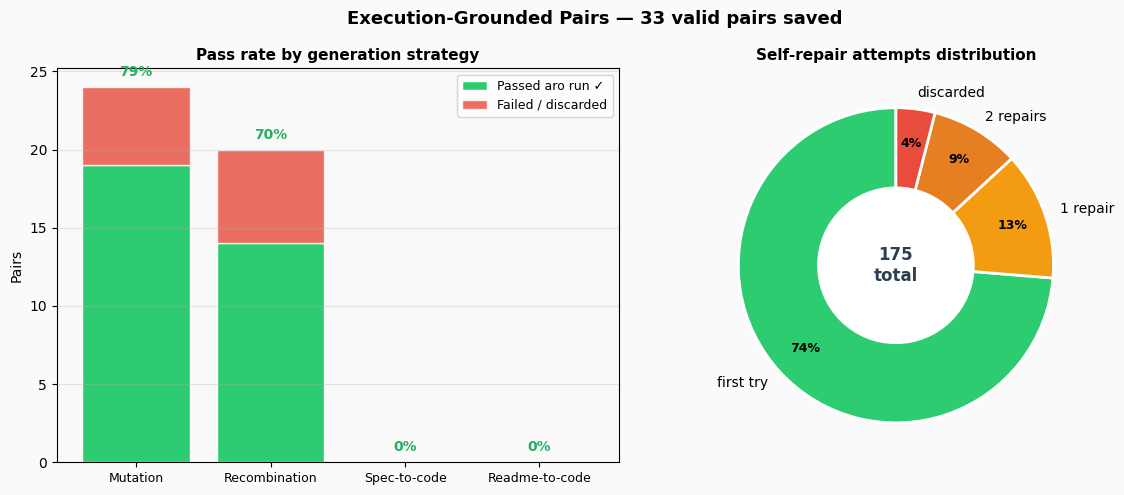

Saved: run/2026-03-27/06_repl_execution_training.png


In [13]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '06_repl_execution_training.png'

_strategies = ['mutation', 'recombination', 'spec_to_code', 'readme_to_code']
_labels     = ['Mutation', 'Recombination', 'Spec-to-code', 'Readme-to-code']
_ok   = [stats[s]['ok']   for s in _strategies]
_fail = [stats[s]['fail']  for s in _strategies]
_rates = [round(100 * o / max(1, o + f)) for o, f in zip(_ok, _fail)]

# Derive repair distribution from the saved results list
_repair_dist = Counter(r.get('repairs', 0) for r in results if r.get('source') != 'readme_to_code')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: stacked bar — ok vs fail per strategy
x = range(len(_strategies))
ax1.bar(x, _ok,   label='Passed aro run ✓', color='#2ecc71', edgecolor='white')
ax1.bar(x, _fail, bottom=_ok, label='Failed / discarded', color='#e74c3c', edgecolor='white', alpha=0.8)
for i, (o, f, r) in enumerate(zip(_ok, _fail, _rates)):
    ax1.text(i, o + f + 0.5, f'{r}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#27ae60')
ax1.set_xticks(list(x))
ax1.set_xticklabels(_labels, fontsize=9)
ax1.set_ylabel('Pairs')
ax1.set_title('Pass rate by generation strategy', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('#f9f9f9')

# Right: donut — repair attempts distribution (0 = first try, N = N repairs, MAX = discarded)
_repair_keys   = sorted(_repair_dist.keys())
_repair_vals   = [_repair_dist[k] for k in _repair_keys]
_repair_labels = [
    ('first try' if k == 0 else f'{k} repair{"s" if k > 1 else ""}' if k < MAX_REPAIR_ATTEMPTS else 'discarded')
    for k in _repair_keys
]
_repair_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'][:len(_repair_vals)]
if _repair_vals:
    wedges, _, autotexts = ax2.pie(
        _repair_vals, labels=_repair_labels, colors=_repair_colors,
        autopct='%1.0f%%', startangle=90, pctdistance=0.78,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')
    ax2.add_artist(plt.Circle((0, 0), 0.50, fc='white'))
    ax2.text(0, 0, f'{sum(_repair_vals)}\ntotal', ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2c3e50')
ax2.set_title('Self-repair attempts distribution', fontsize=11, fontweight='bold')

_total_ok = sum(_ok)
fig.suptitle(f'Execution-Grounded Pairs — {_total_ok:,} valid pairs saved',
             fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')


In [14]:
# ── Samples per category ─────────────────────────────────────────────────────
import json, random
from collections import defaultdict

_pairs = []
if OUTPUT_FILE.exists():
    with open(OUTPUT_FILE) as f:
        for line in f:
            if line.strip():
                _pairs.append(json.loads(line))

_by_src = defaultdict(list)
for p in _pairs:
    _by_src[p.get('source', 'unknown')].append(p)

_CATEGORY_ORDER = ['readme_to_code', 'mutation', 'recombination', 'spec_to_code', 'repair']
SAMPLES_PER_CAT = 2

for src in _CATEGORY_ORDER:
    pool = _by_src.get(src, [])
    if not pool:
        continue
    print(f'\n{"─"*72}')
    print(f'  {src}  ({len(pool)} pairs)')
    print('─'*72)
    for s in random.sample(pool, min(SAMPLES_PER_CAT, len(pool))):
        print(f'Q: {s["instruction"][:220]}')
        out = s.get('output', '')
        print(f'A: {out[:320]}{"..." if len(out) > 320 else ""}')
        print()


────────────────────────────────────────────────────────────────────────
  readme_to_code  (15 pairs)
────────────────────────────────────────────────────────────────────────
Q: Write a complete, runnable ARO application that demonstrates:
- Request action
- URL handling
- Response logging
- Stateless HTTP calls
Include Application-Start and visible Log output. Output only the ARO source code.
A: (* HTTP Client Example - Fetching data from external API *)

(Application-Start: HTTP Client Demo) {
    Log "HTTP Client Demo" to the <console>.
    Log "Fetching weather data from Open-Meteo API..." to the <console>.

    (* Create the API URL *)
    Create the <api-url> with "https://api.open-meteo.com/v1/forecast?l...

Q: Write a complete, runnable ARO application that demonstrates:
- Guarded statements
- Match expressions
- Comparison operators
- String and numeric matching
Include Application-Start and visible Log output. Output only th
A: (*
 * ARO-0004 Conditional Branching Example
 *